In [66]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import torch.nn as nn
import torch
from torchvision.models import resnet18, ResNet18_Weights
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *
from torch.utils.data import Dataset, DataLoader


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
path_train = Path('../data/stage1_train')

df = pd.read_csv('instance_eval_watershed.csv')
df_sorted_error = df.sort_values(by = 'count_error', ascending=False)
df_sorted_map = df.sort_values(by = 'mAP_image')

df_sorted_error.head(5)


,id,n_gt,n_pred,count_error,mAP_image
15,20b20ab049372d184c705acebe7af026d3580f5fd5a72e...,289,9,280,0.000000
56,0ea221716cf13710214dcd331a61cea48308c3940df1d2...,369,139,230,0.003996
64,5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b9375...,272,127,145,0.006718
22,8efed2e62c919e6d70a2ab548b1a33014877fe8a23f177...,260,139,121,0.005392
16,8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc...,94,0,94,0.000000


In [68]:
full_train_ds = DSB2018TernaryDataset(path_train)
n = len(full_train_ds)
n_val = int(0.15 * n)
n_train = n - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_train_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                            collate_fn=collate_fn_ternary)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False,
                            collate_fn=collate_fn_ternary)


In [69]:
df_sorted_map.head(5)

,id,n_gt,n_pred,count_error,mAP_image
13,220b37f4ca7cab486d2b71cd87a46ee7411a5aa142799d...,1,3,2,0.0
15,20b20ab049372d184c705acebe7af026d3580f5fd5a72e...,289,9,280,0.0
8,af576e8ec3a8d0b57eb6a311299e9e4fd2047970d3dd9d...,2,3,1,0.0
16,8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc...,94,0,94,0.0
89,e5aeb5b3577abbebe8982b5dd7d22c4257250ad3000661...,2,1,1,0.0


In [70]:
# Analisar as falhas

top_5_ids = df_sorted_error['id'].head(5).to_list()
top_5_ids

['20b20ab049372d184c705acebe7af026d3580f5fd5a72ed796e3622e1685af2f',
 '0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1',
 '5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b93758a75e9956f1513c5a3',
 '8efed2e62c919e6d70a2ab548b1a33014877fe8a23f177ef25a9dee25ffe8842',
 '8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc6d41760fb92ae23ab4']

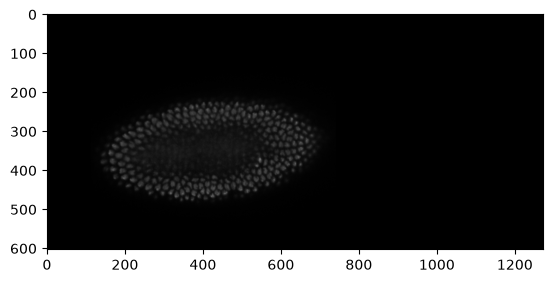

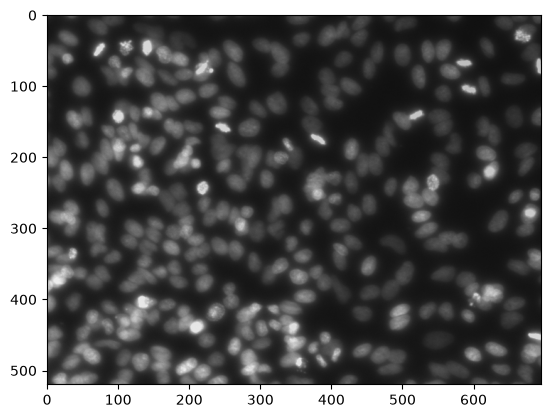

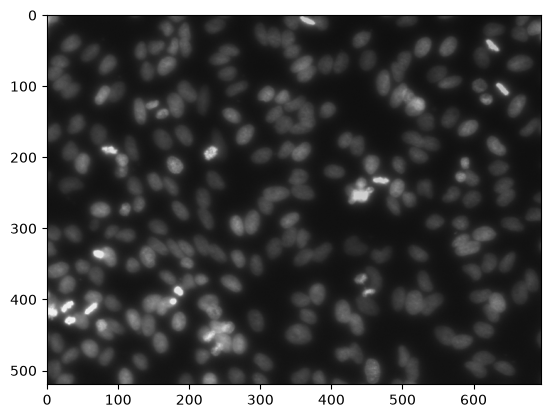

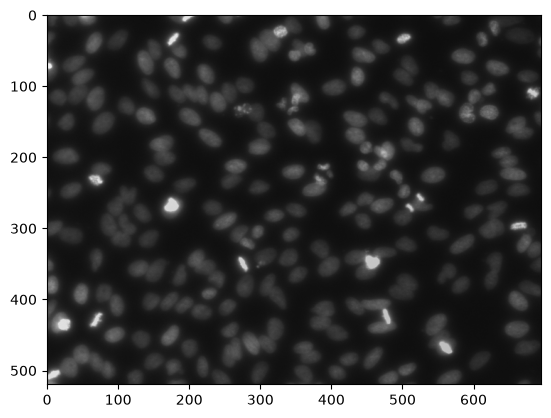

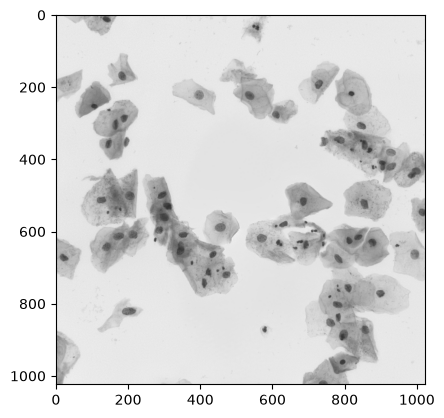

In [71]:
for img_id in top_5_ids:
    img_path = path_train / img_id / 'images' / f'{img_id}.png'
    mask_dir = path_train / img_id / 'masks'

    image = np.array(Image.open(img_path).convert('RGB'))
    plt.imshow(image)
    plt.show()

In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights


class UNetTernaryDilated(nn.Module):

    def __init__(self, dilation=2):
        super().__init__()

        # ============================================================
        # ENCODER
        # ============================================================

        resnet = resnet18(
            weights=ResNet18_Weights.IMAGENET1K_V1
        )

        self.enc1 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.pool = resnet.maxpool

        self.enc2 = resnet.layer1
        self.enc3 = resnet.layer2
        self.enc4 = resnet.layer3

        # ============================================================
        # DILATION NO LAYER 3
        # ============================================================

        for i, block in enumerate(self.enc4):

            # Retira o downsampling do primeiro bloco
            if i == 0:
                block.conv1.stride = (1, 1)

                if block.downsample is not None:
                    block.downsample[0].stride = (1, 1)

            # dilation
            block.conv1.dilation = (dilation, dilation)
            block.conv1.padding = (dilation, dilation)

            block.conv2.dilation = (dilation, dilation)
            block.conv2.padding = (dilation, dilation)

        # ============================================================
        # DECODER
        # ============================================================

        self.up3 = nn.Conv2d(
            256, 128,
            kernel_size=1
        )

        self.dec3 = nn.Sequential(
            nn.Conv2d(
                256, 128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.Conv2d(
                128, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        self.dec1 = nn.Sequential(
            nn.Conv2d(
                128, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        self.up0 = nn.Conv2d(
            64, 32,
            kernel_size=3,
            padding=1
        )

        self.segmentation_head = nn.Conv2d(
            32, 3,
            kernel_size=1
        )

    def forward(self, x):

        # ============================================================
        # ENCODER
        # ============================================================

        x1 = self.enc1(x)                 # H/2
        x2 = self.enc2(self.pool(x1))     # H/4
        x3 = self.enc3(x2)                # H/8
        x4 = self.enc4(x3)                # H/8 (dilation)

        # ============================================================
        # DECODER
        # ============================================================

        # x4 e x3 têm a mesma resolução
        d3 = self.dec3(
            torch.cat([
                self.up3(x4),
                x3
            ], dim=1)
        )

        # H/8 -> H/4
        d3_up = F.interpolate(
            d3,
            size=x2.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        d2 = self.dec2(d3_up)

        # H/4 -> H/2
        d2_up = F.interpolate(
            d2,
            size=x1.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        d1 = self.dec1(
            torch.cat([
                d2_up,
                x1
            ], dim=1)
        )

        # H/2 -> H
        d1_up = F.interpolate(
            d1,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        d0 = self.up0(d1_up)

        return self.segmentation_head(d0)

## Parte 5 (obrigatório) — Campo receptivo teórico do encoder

O campo receptivo teórico é calculado seguindo apenas o ramo convolucional principal dos BasicBlock do ResNet18. As convoluções das conexões residuais (skip connections) não são acumuladas como operações sequenciais, pois pertencem a um ramo paralelo.

In [73]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')

model_correction = UNetTernaryDilated().to(DEVICE)

x = torch.randn(2, 3, 128, 128).to(DEVICE)

with torch.no_grad():
    y = model_correction(x)

print("Input :", x.shape)
print("Output:", y.shape)

Input : torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])


In [74]:
import torch.nn as nn


def update_rf(r, jump, kernel, stride=1, dilation=1):
    """
    Atualiza receptive field e jump para uma operação convolucional/pooling.
    """
    r = r + ((kernel - 1) * dilation) * jump
    jump = jump * stride
    return r, jump


def resnet18_encoder_rf(model):
    """
    Calcula o receptive field teórico do ramo principal do encoder
    ResNet18 usado pelo UNetTernary.

    Não conta convoluções dos downsample/skip connections como se
    fossem executadas sequencialmente.
    """

    r = 1
    jump = 1

    # ResNet conv1: 7x7, stride 2
    r, jump = update_rf(r, jump, kernel=7, stride=2)

    # MaxPool: 3x3, stride 2
    r, jump = update_rf(r, jump, kernel=3, stride=2)

    # ---------------------------------------------------------
    # layer1: 2 BasicBlocks
    # ---------------------------------------------------------
    for block in model.enc2:
        r, jump = update_rf(
            r, jump,
            kernel=3,
            stride=block.conv1.stride[0],
            dilation=block.conv1.dilation[0]
        )

        r, jump = update_rf(
            r, jump,
            kernel=3,
            stride=block.conv2.stride[0],
            dilation=block.conv2.dilation[0]
        )

    # ---------------------------------------------------------
    # layer2: 2 BasicBlocks
    # ---------------------------------------------------------
    for block in model.enc3:
        r, jump = update_rf(
            r, jump,
            kernel=3,
            stride=block.conv1.stride[0],
            dilation=block.conv1.dilation[0]
        )

        r, jump = update_rf(
            r, jump,
            kernel=3,
            stride=block.conv2.stride[0],
            dilation=block.conv2.dilation[0]
        )

    # ---------------------------------------------------------
    # layer3: 2 BasicBlocks
    # ---------------------------------------------------------
    for block in model.enc4:
        r, jump = update_rf(
            r, jump,
            kernel=3,
            stride=block.conv1.stride[0],
            dilation=block.conv1.dilation[0]
        )

        r, jump = update_rf(
            r, jump,
            kernel=3,
            stride=block.conv2.stride[0],
            dilation=block.conv2.dilation[0]
        )

    return r, jump


model_baseline = UNetTernary()
model_dilated = UNetTernaryDilated()

rf_baseline, stride_baseline = resnet18_encoder_rf(model_baseline)
rf_dilated, stride_dilated = resnet18_encoder_rf(model_dilated)

print(
    f"Encoder padrão   : RF = {rf_baseline} px | "
    f"output stride = {stride_baseline}"
)

print(
    f"Encoder dilatado : RF = {rf_dilated} px | "
    f"output stride = {stride_dilated}"
)

print(
    f"\nVariação do RF: {rf_dilated - rf_baseline:+d} px"
)

print(
    f"Resolução relativa da saída: "
    f"{stride_baseline / stride_dilated:.1f}x maior no encoder dilatado"
)

Encoder padrão   : RF = 211 px | output stride = 16
Encoder dilatado : RF = 227 px | output stride = 8

Variação do RF: +16 px
Resolução relativa da saída: 2.0x maior no encoder dilatado


## Distribuição de tamanhos dos objetos do dataset vs. campo receptivo

Percorremos as máscaras individuais (`.../masks/*.png`) de todo o `stage1_train`, medimos o diâmetro equivalente de cada núcleo e comparamos essa distribuição com o RF teórico calculado acima.

29288 instâncias | diâmetro médio = 7.0 px | mediana = 6.0 px | p95 = 16.2 px | máximo = 41.8 px

Objetos com diâmetro <= 8 px: 72.75%
Objetos com diâmetro <= 16 px: 94.86%
Objetos com diâmetro > 16 px: 5.14%


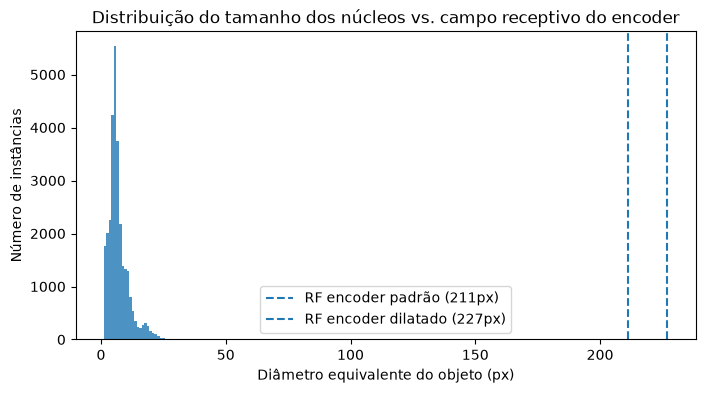

0.00% das instâncias têm diâmetro maior que o RF do encoder padrão.
0.00% das instâncias têm diâmetro maior que o RF do encoder dilatado.


In [75]:
from skimage.measure import label, regionprops
import glob


IMG_SIZE = 128


def object_diameters(train_dir, target_size=IMG_SIZE):
    """
    Calcula o diâmetro equivalente das instâncias na mesma escala
    espacial usada como entrada do modelo.

    As máscaras são redimensionadas para target_size x target_size
    antes da medição.
    """

    diameters = []

    mask_paths = glob.glob(
        str(train_dir / "*" / "masks" / "*.png")
    )

    for p in mask_paths:

        mask = np.array(Image.open(p))

        # Redimensiona usando nearest neighbor para preservar os rótulos
        mask_resized = np.array(
            Image.fromarray(mask.astype(np.uint8)).resize(
                (target_size, target_size),
                resample=Image.Resampling.NEAREST
            )
        )

        lab = label(mask_resized > 0)

        for region in regionprops(lab):
            diameters.append(
                region.equivalent_diameter_area
            )

    return np.array(diameters)

diameters = object_diameters(path_train)

print(
    f"{len(diameters)} instâncias | "
    f"diâmetro médio = {diameters.mean():.1f} px | "
    f"mediana = {np.median(diameters):.1f} px | "
    f"p95 = {np.percentile(diameters, 95):.1f} px | "
    f"máximo = {diameters.max():.1f} px"
)

# Comparação entre o tamanho dos objetos e o output stride
print(
    f"\nObjetos com diâmetro <= {stride_baseline/2:.0f} px: "
    f"{(diameters <= stride_baseline/2).mean()*100:.2f}%"
)

print(
    f"Objetos com diâmetro <= {stride_baseline:.0f} px: "
    f"{(diameters <= stride_baseline).mean()*100:.2f}%"
)

print(
    f"Objetos com diâmetro > {stride_baseline:.0f} px: "
    f"{(diameters > stride_baseline).mean()*100:.2f}%"
)

plt.figure(figsize=(8, 4))

plt.hist(
    diameters,
    bins=40,
    alpha=0.8
)

plt.axvline(
    rf_baseline,
    linestyle="--",
    label=f"RF encoder padrão ({rf_baseline}px)"
)

plt.axvline(
    rf_dilated,
    linestyle="--",
    label=f"RF encoder dilatado ({rf_dilated}px)"
)

plt.xlabel("Diâmetro equivalente do objeto (px)")
plt.ylabel("Número de instâncias")

plt.title(
    "Distribuição do tamanho dos núcleos "
    "vs. campo receptivo do encoder"
)

plt.legend()
plt.show()


frac_maior_que_rf = (
    diameters > rf_baseline
).mean() * 100

frac_maior_que_rf_dilated = (
    diameters > rf_dilated
).mean() * 100

print(
    f"{frac_maior_que_rf:.2f}% das instâncias "
    f"têm diâmetro maior que o RF do encoder padrão."
)

print(
    f"{frac_maior_que_rf_dilated:.2f}% das instâncias "
    f"têm diâmetro maior que o RF do encoder dilatado."
)


## Reconstruir os mapas intermediários (fronteira) e as instâncias por watershed

Para montar a figura de cada falha (imagem, GT, predição, mapa intermediário) precisamos rodar o modelo final nas 5 imagens selecionadas. **Ajuste `CHECKPOINT_PATH`** para o arquivo de pesos do `UNetTernary` que gerou o `instance_eval_watershed.csv`.

> Se vocês já têm a função de decodificação por watershed usada para gerar esse CSV, > substituam `decode_watershed` abaixo por ela — o importante é manter a mesma regra de > decodificação usada na avaliação, para a figura ser consistente com o número reportado.

In [76]:
import torch.nn.functional as F
from scipy import ndimage as ndi
from skimage.segmentation import watershed

CHECKPOINT_PATH = "../notebooks/best_model_ternary.pt"  # <-- ajustar

device = "cuda" if torch.cuda.is_available() else "cpu"
model_final = UNetTernary().to(device)
model_final.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model_final.eval()

# Convenção de canais assumida: 0 = fundo, 1 = interior, 2 = fronteira
BG, INTERIOR, BOUNDARY = 0, 1, 2


def decode_watershed(logits, min_interior_size=5):
    """logits: tensor [3, H, W] (saída crua do UNetTernary para uma imagem).
    Retorna (boundary_prob [H,W], pred_instances [H,W] rotulado)."""
    probs = F.softmax(logits, dim=0).cpu().numpy()
    boundary_prob = probs[BOUNDARY]

    interior_mask = probs[INTERIOR] > probs[BOUNDARY]
    interior_mask &= probs[INTERIOR] > probs[BG]
    foreground = interior_mask | (boundary_prob > 0.5)

    markers, n = ndi.label(interior_mask)
    # remove marcadores minúsculos (ruído)
    sizes = ndi.sum(interior_mask, markers, range(1, n + 1))
    for i, s in enumerate(sizes, start=1):
        if s < min_interior_size:
            markers[markers == i] = 0

    pred_instances = watershed(boundary_prob, markers=markers, mask=foreground)
    return boundary_prob, pred_instances


def load_instance_gt(mask_dir):
    """Empilha as máscaras individuais do DSB2018 em um único array rotulado (H, W)."""
    mask_dir = Path(mask_dir)
    gt = None
    for i, p in enumerate(sorted(mask_dir.glob("*.png")), start=1):
        m = np.array(Image.open(p)) > 0
        if gt is None:
            gt = np.zeros(m.shape, dtype=np.int32)
        gt[m] = i
    return gt


## Galeria de falhas — imagem, GT, predição e mapa de fronteira, com diagnóstico

Para cada uma das 5 piores imagens (por erro de contagem), geramos a figura completa e comparamos o diâmetro do maior objeto com o RF teórico calculado acima, no mesmo formato de diagnóstico pedido no enunciado.

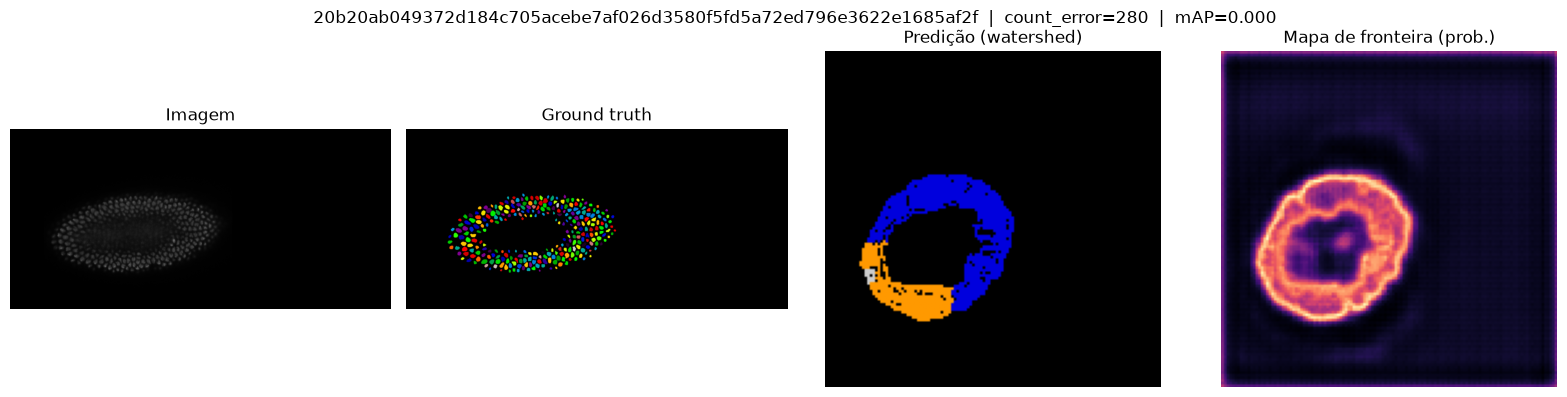

[20b20ab049372d184c705acebe7af026d3580f5fd5a72ed796e3622e1685af2f] O maior objeto tem aproximadamente 3.0 px de diâmetro, enquanto o RF teórico do encoder padrão é 211 px. Como o maior objeto é muito menor que o RF, não há evidência de que a falta de campo receptivo seja a causa principal desta falha. O output stride de 16 px, entretanto, é comparável à escala dos objetos e pode levar à perda de detalhes espaciais necessários para representar interiores e fronteiras de instâncias pequenas.


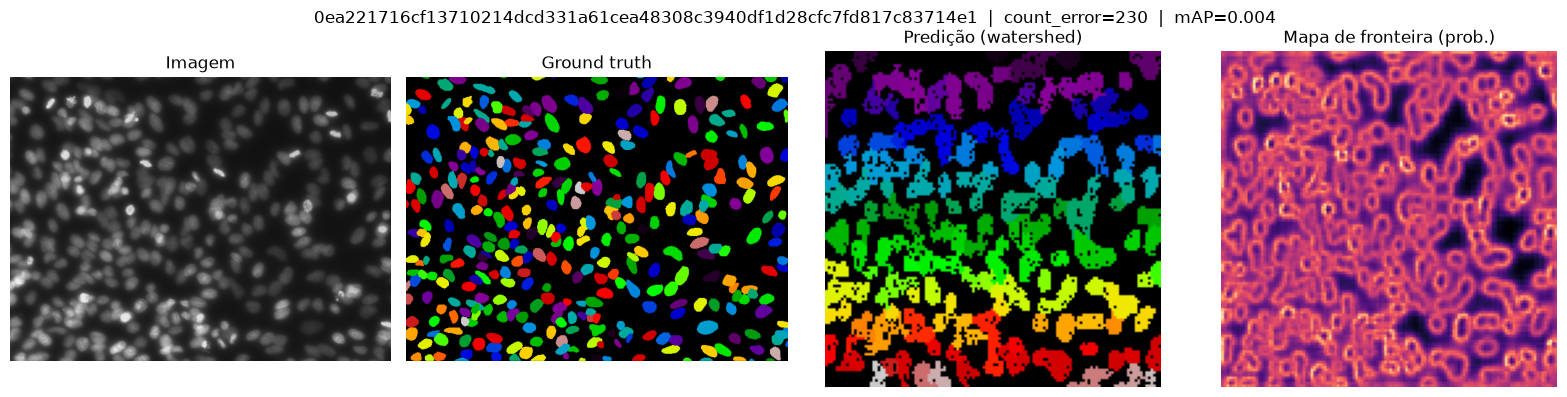

[0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1] O maior objeto tem aproximadamente 6.6 px de diâmetro, enquanto o RF teórico do encoder padrão é 211 px. Como o maior objeto é muito menor que o RF, não há evidência de que a falta de campo receptivo seja a causa principal desta falha. O output stride de 16 px, entretanto, é comparável à escala dos objetos e pode levar à perda de detalhes espaciais necessários para representar interiores e fronteiras de instâncias pequenas.


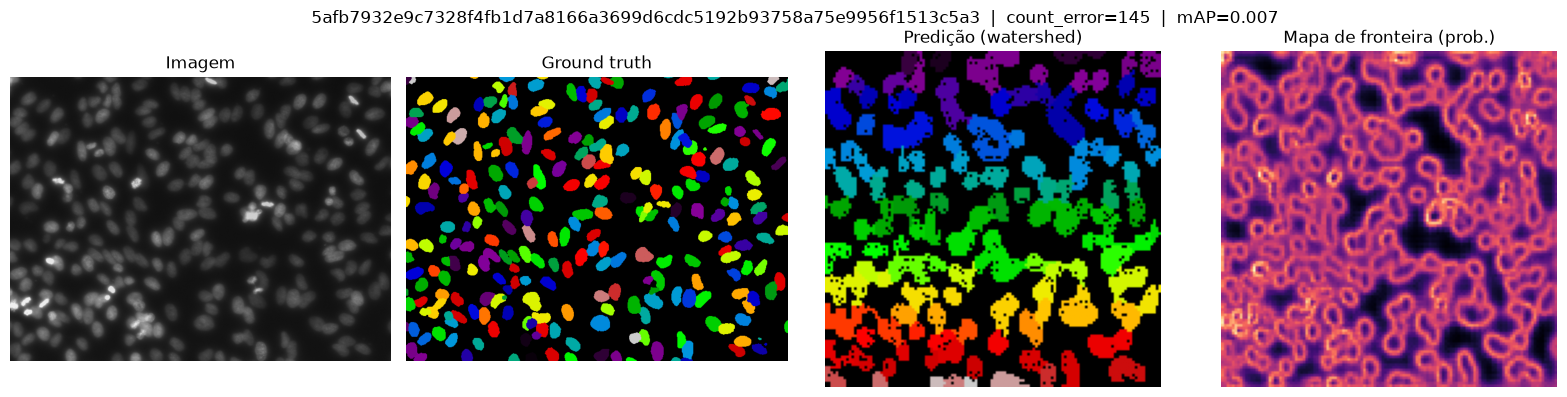

[5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b93758a75e9956f1513c5a3] O maior objeto tem aproximadamente 7.2 px de diâmetro, enquanto o RF teórico do encoder padrão é 211 px. Como o maior objeto é muito menor que o RF, não há evidência de que a falta de campo receptivo seja a causa principal desta falha. O output stride de 16 px, entretanto, é comparável à escala dos objetos e pode levar à perda de detalhes espaciais necessários para representar interiores e fronteiras de instâncias pequenas.


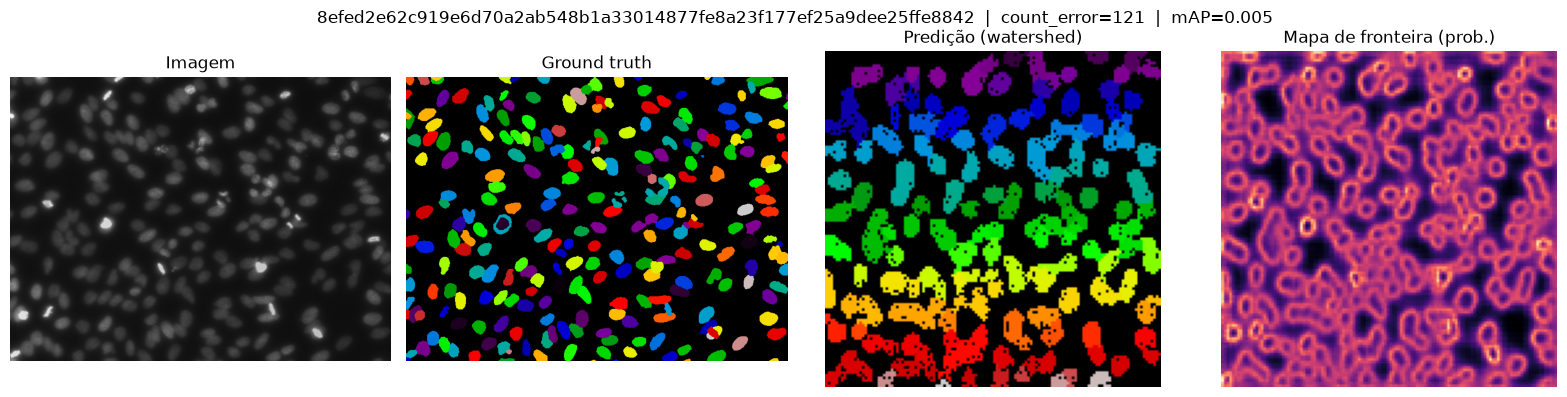

[8efed2e62c919e6d70a2ab548b1a33014877fe8a23f177ef25a9dee25ffe8842] O maior objeto tem aproximadamente 6.4 px de diâmetro, enquanto o RF teórico do encoder padrão é 211 px. Como o maior objeto é muito menor que o RF, não há evidência de que a falta de campo receptivo seja a causa principal desta falha. O output stride de 16 px, entretanto, é comparável à escala dos objetos e pode levar à perda de detalhes espaciais necessários para representar interiores e fronteiras de instâncias pequenas.


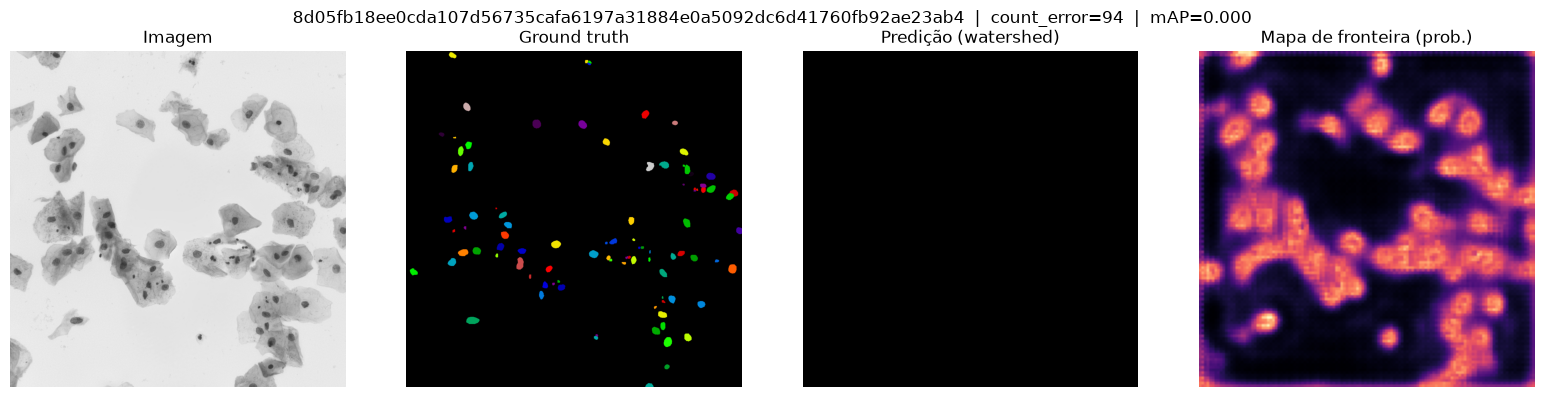

[8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc6d41760fb92ae23ab4] O maior objeto tem aproximadamente 4.1 px de diâmetro, enquanto o RF teórico do encoder padrão é 211 px. Como o maior objeto é muito menor que o RF, não há evidência de que a falta de campo receptivo seja a causa principal desta falha. O output stride de 16 px, entretanto, é comparável à escala dos objetos e pode levar à perda de detalhes espaciais necessários para representar interiores e fronteiras de instâncias pequenas.


In [77]:
import torchvision.transforms.functional as TF

IMG_SIZE = 128  # ajustar para o tamanho de entrada usado no treino, se diferente

diagnósticos = []

for img_id in top_5_ids:
    img_path = path_train / img_id / "images" / f"{img_id}.png"
    mask_dir = path_train / img_id / "masks"

    image = np.array(Image.open(img_path).convert("RGB"))
    gt_instances = load_instance_gt(mask_dir)

    inp = TF.to_tensor(Image.fromarray(image).resize((IMG_SIZE, IMG_SIZE))).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model_final(inp)[0]
    boundary_prob, pred_instances = decode_watershed(logits)


    gt_resized = np.array(
    Image.fromarray(
        gt_instances.astype(np.int32)
    ).resize(
        (IMG_SIZE, IMG_SIZE),
        resample=Image.Resampling.NEAREST
    )
    )

    diam = [
        r.equivalent_diameter_area
        for r in regionprops(gt_resized)
    ]

    max_diam = max(diam) if diam else 0
    
    linha = df[df["id"] == img_id].iloc[0]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(image); axes[0].set_title("Imagem"); axes[0].axis("off")
    axes[1].imshow(gt_instances, cmap="nipy_spectral"); axes[1].set_title("Ground truth"); axes[1].axis("off")
    axes[2].imshow(pred_instances, cmap="nipy_spectral"); axes[2].set_title("Predição (watershed)"); axes[2].axis("off")
    axes[3].imshow(boundary_prob, cmap="magma"); axes[3].set_title("Mapa de fronteira (prob.)"); axes[3].axis("off")
    fig.suptitle(f"{img_id}  |  count_error={linha['count_error']}  |  mAP={linha['mAP_image']:.3f}")
    plt.tight_layout()
    plt.show()

    veredito = "MAIOR" if max_diam > rf_baseline else "menor"
    diagnostico = (
    f"[{img_id}] O maior objeto tem aproximadamente "
    f"{max_diam:.1f} px de diâmetro, enquanto o RF teórico "
    f"do encoder padrão é {rf_baseline} px. "
    f"Como o maior objeto é muito menor que o RF, "
    f"não há evidência de que a falta de campo receptivo "
    f"seja a causa principal desta falha. "
    f"O output stride de {stride_baseline} px, entretanto, "
    f"é comparável à escala dos objetos e pode levar à perda "
    f"de detalhes espaciais necessários para representar "
    f"interiores e fronteiras de instâncias pequenas."
)

    print(diagnostico)
    diagnósticos.append(diagnostico)


## Gerar rótulo ternário (fundo / interior / fronteira) a partir das máscaras individuais

Usado no treino de `UNetTernary`/`UNetTernaryDilated` com perda CE balanceada. A fronteira é obtida por dilatação de cada instância individual e depois interseção entre instâncias vizinhas — assim ela existe só onde dois objetos se tocam ou ficam próximos, e não na borda externa de um objeto isolado contra o fundo.

In [78]:
from scipy.ndimage import binary_dilation


def instance_gt_to_ternary(instance_gt, boundary_width=2):
    """instance_gt: array (H, W) com um inteiro por instância (0 = fundo).
    Retorna array (H, W) com rótulos {0: fundo, 1: interior, 2: fronteira}."""
    ids = np.unique(instance_gt)
    ids = ids[ids != 0]
    struct = np.ones((3, 3), dtype=bool)

    dilated_sum = np.zeros(instance_gt.shape, dtype=np.uint8)
    for i in ids:
        inst_mask = instance_gt == i
        dilated = binary_dilation(inst_mask, structure=struct, iterations=boundary_width)
        dilated_sum += dilated.astype(np.uint8)

    boundary = dilated_sum > 1          # pixels cobertos por >=2 instâncias dilatadas
    interior = (instance_gt > 0) & ~boundary

    ternary = np.zeros(instance_gt.shape, dtype=np.int64)
    ternary[interior] = 1
    ternary[boundary] = 2
    return ternary


## Correção proposta: aumentar a resolução do encoder com convolução dilatada

O diagnóstico indica que a limitação não está no campo receptivo teórico:
o RF do encoder padrão é de 211 px, enquanto o maior objeto observado
possui apenas 41,8 px de diâmetro.

Por outro lado, os objetos são pequenos: a mediana é de aproximadamente
6 px e o P95 é de 16,2 px. O encoder padrão possui output stride 16,
fazendo com que a representação mais profunda tenha resolução de apenas
8×8 para entradas de 128×128.

Assim, a hipótese investigada é que o downsampling excessivo pode
prejudicar a representação de objetos pequenos e, principalmente, das
fronteiras entre instâncias próximas.

Como correção, substituímos o downsampling de `layer3` por convoluções
dilatadas. Dessa forma, o encoder passa de output stride 16 para 8,
mantendo uma representação espacial duas vezes mais densa, enquanto
aumenta ligeiramente o campo receptivo teórico de 211 para 227 px.

A correção será validada treinando o mesmo modelo ternário com essa
alteração e comparando mAP e erro de contagem antes e depois.

In [79]:
# from functions import calculate_instance_metrics

class_weights = torch.tensor([0.2, 0.4, 1.0])  # [fundo, interior, fronteira] -- ajustar

def train_ternary(model, dataloader, device, num_epochs=10, lr=1e-3):
    model.to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device)
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for images, masks, instance_gt, _, _ in dataloader:
            images = images.to(device)
            masks = masks.to(device).long()

            optimizer.zero_grad()

            logits = model(images)

            loss = criterion(logits, masks)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Loss: {avg_loss:.4f}"
        )



def individual_masks_to_instances(individual_masks, shape=(128, 128)):
    instance_gt = np.zeros(shape, dtype=np.int32)

    for instance_id, mask in enumerate(individual_masks, start=1):
        mask = np.asarray(mask).astype(bool)
        instance_gt[mask] = instance_id

    return instance_gt



def evaluate_ternary(model, dataloader, device):

    model.eval()

    all_mAPs = []
    all_count_errors = []

    for images, _, _, individual_masks, _ in dataloader:

        images = images.to(device)

        with torch.no_grad():
            logits = model(images)

        for i in range(images.size(0)):

            _, pred_instances = decode_watershed(logits[i])

            # Ground truth instance-aware
            gt = individual_masks_to_instances(
                individual_masks[i],
                shape=images.shape[-2:]
            )

            mAP, count_error, _ = calculate_instance_metrics(
                gt,
                pred_instances
            )

            all_mAPs.append(mAP)
            all_count_errors.append(count_error)

    return np.mean(all_mAPs), np.mean(all_count_errors)
model_baseline = UNetTernary().to(device)

checkpoint = torch.load(
    "best_model_ternary.pt",
    map_location=device
)

model_baseline.load_state_dict(checkpoint)

mAP_before, count_error_before = evaluate_ternary(
    model_baseline,
    val_loader,
    device
)

print("Baseline")
print(f"mAP          : {mAP_before:.4f}")
print(f"count_error  : {count_error_before:.2f}")

Baseline
mAP          : 0.1978
count_error  : 19.45


In [80]:
torch.manual_seed(42)

model_correction = UNetTernaryDilated().to(device)

train_ternary(
    model_correction,
    train_loader,
    device,
    num_epochs=10
)

mAP_after, count_error_after = evaluate_ternary(
    model_correction,
    val_loader,
    device
)

print("\nBefore / After")
print(f"{'':20s}{'mAP':>10s}{'count_error':>15s}")  
print(f"{'Baseline':20s}{mAP_before:10.4f}{count_error_before:15.2f}")
print(f"{'Dilated':20s}{mAP_after:10.4f}{count_error_after:15.2f}")

Epoch 1/10 | Loss: 0.6680
Epoch 2/10 | Loss: 0.4303
Epoch 3/10 | Loss: 0.3367
Epoch 4/10 | Loss: 0.3263
Epoch 5/10 | Loss: 0.3003
Epoch 6/10 | Loss: 0.2925
Epoch 7/10 | Loss: 0.2713
Epoch 8/10 | Loss: 0.2794
Epoch 9/10 | Loss: 0.2671
Epoch 10/10 | Loss: 0.2487

Before / After
                           mAP    count_error
Baseline                0.1978          19.45
Dilated                 0.2633          23.98


## Resultado da correção

A correção proposta consistiu na utilização de convoluções dilatadas no último bloco do encoder, buscando reduzir a perda de informação espacial causada pelo downsampling e, consequentemente, melhorar a representação de objetos pequenos.

O modelo baseline apresentou **mAP de 0,1978** e **erro médio de contagem de 19,45**. Após a alteração, o modelo dilatado apresentou **mAP de 0,2633**, representando um aumento relativo de aproximadamente **33,9%**. Entretanto, o erro de contagem aumentou para **23,98**.

| Modelo | mAP | Erro de contagem |
|---|---:|---:|
| Baseline | 0,1978 | 19,45 |
| Dilated | **0,2633** | 23,98 |
| Variação | **+33,9%** | **+23,3%** |

A melhora do mAP sugere que a utilização de uma representação espacial mais detalhada contribuiu para uma melhor localização e sobreposição das instâncias. No entanto, o aumento do erro de contagem indica que essa alteração não resolveu completamente o problema de detecção das células.

Assim, os resultados fornecem evidências de que a perda de informação espacial decorrente do downsampling é um fator relevante para o desempenho do modelo, especialmente considerando que a maioria dos objetos possui dimensões muito pequenas. Por outro lado, o resultado também indica que existem outros fatores limitantes, possivelmente relacionados à geração dos marcadores e ao pós-processamento baseado em watershed.

Portanto, a correção **melhorou a qualidade da segmentação das instâncias segundo o mAP, mas não melhorou a capacidade de estimar corretamente o número de instâncias**. Isso sugere que a hipótese inicial explica parte das falhas observadas, mas não todo o problema.